In [1]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [2]:
pits_short_mask = np.load('outputs/coverage_eval2/pit_coverage_mask_short.npz', allow_pickle=True)

# Access individual arrays
alpha_s = pits_short_mask['alpha']
coverage_s = pits_short_mask['coverage']
pits_s = pits_short_mask['pits']
labels_s = pits_short_mask['labels']
hyperparameters_s = pits_short_mask['hyperparameters']

In [5]:
pits_long_mask = np.load('outputs/coverage_eval2/pit_coverage_mask_long.npz', allow_pickle=True)

# Access individual arrays
alpha = pits_long_mask['alpha']
coverage = pits_long_mask['coverage']
pits = pits_long_mask['pits']
labels = pits_long_mask['labels']
hyperparameters = pits_long_mask['hyperparameters']

In [6]:
pits_s.shape

(11, 100000)

In [7]:
color1 = '#1b7a52'
color2 = '#2ecf8b'

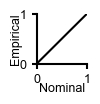

In [8]:
fig = plt.figure(figsize=(0.65, .65))

plt.plot(alpha_s, coverage_s.mean(0), color="black")
plt.xlabel('Nominal', labelpad=-2.5)
plt.ylabel('Empirical', labelpad=-1.5)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xticks([0,1], [0,1])
plt.yticks([0,1], [0,1])
fig.savefig("dmri_model_coverage.svg", dpi=300, bbox_inches='tight', transparent=True)

In [35]:
def random_errors(key, counts):

    def best_calibrated_errors(key):
        u = jax.random.uniform(key, shape=(counts,))
        alpha = jnp.linspace(0, 1, alpha_s.shape[0])
        cov = jnp.quantile(u, alpha)
        error = jnp.abs(cov - alpha).mean()
        return error
    keys = jax.random.split(key, num=100_000)
    errors = jax.lax.map(best_calibrated_errors,keys, batch_size=1000)
    q005 = jnp.quantile(errors, 0.005)
    q995 = jnp.quantile(errors, 0.995)
    return q005, q995

In [36]:
lower_m, upper_u = random_errors(jax.random.PRNGKey(0), 100000)
lower_t, upper_t = random_errors(jax.random.PRNGKey(0), 10_000)

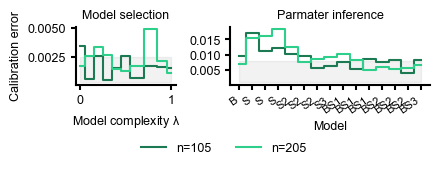

In [37]:
# Combined mask + theta calibration error
errors_long_mask = [jnp.abs(cov - alpha).mean() for cov in coverage]
errors_short_mask = [jnp.abs(cov - alpha_s).mean() for cov in coverage_s]
mask_short = ~np.isnan(hyperparameters_s)
mask_long = ~np.isnan(hyperparameters)

pits_short_theta = np.load('outputs/coverage_eval2/pit_coverage_theta_short.npz', allow_pickle=True)
pits_long_theta = np.load('outputs/coverage_eval2/pit_coverage_theta_long.npz', allow_pickle=True)



errors_theta_short = np.asarray(pits_short_theta['theta_mask_errors'])
errors_theta_long = np.asarray(pits_long_theta['theta_mask_errors'])
labels_theta = [str(label) for label in np.atleast_1d(pits_short_theta['theta_mask_labels'])]

positions = np.arange(len(labels_theta))

fig, axes = plt.subplots(1, 2, figsize=(4.4, 1.5), width_ratios=[0.5, 1])

axes[0].step(np.asarray(hyperparameters_s)[mask_short], np.asarray(errors_short_mask)[mask_short], color=color1, where='mid', label='n=105')
axes[0].step(np.asarray(hyperparameters)[mask_long], np.asarray(errors_long_mask)[mask_long], color=color2, where='mid', label='n=205')
axes[0].fill_between(hyperparameters_s[mask_short], lower_m, upper_u, color="grey", alpha=0.1)
axes[0].set_xlabel(r'Model complexity $\lambda$')
axes[0].set_ylabel('Calibration error')
axes[0].set_title('Model selection')
#axes[0].grid(True, linestyle='--', alpha=0.3,)

axes[1].step(positions, errors_theta_short, color=color1, where='mid', label='Short')
axes[1].step(positions, errors_theta_long, color=color2, where='mid', label='Long')
axes[1].fill_between(positions, lower_t, upper_t, color="grey", alpha=0.1)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels_theta, rotation=35, ha='right', fontsize=8)
axes[1].set_xlabel('Model')
axes[1].set_title('Parmater inference')
#axes[1].grid(True, linestyle='--', alpha=0.3)
#axes[1].legend(frameon=False)
fig.legend(frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.1), handles=axes[0].get_lines())
fig.tight_layout()
fig.savefig('coverage_calibration_error.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('coverage_calibration_error.svg', bbox_inches='tight', transparent=True)

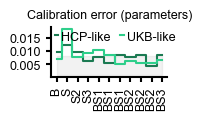

In [45]:
fig, axes = plt.subplots(1, 1, figsize=(1.5, 0.65))
axes = [axes]
subset = [0, 3, 5, 7,8, 9, 10, 11, 12, 13, 14]
subset_positions = np.arange(len(subset))
subset_labels = [labels_theta[i] for i in subset]

axes[0].step(subset_positions, errors_theta_short[subset], color=color1, where='mid', label='HCP-like')
axes[0].step(subset_positions, errors_theta_long[subset], color=color2, where='mid', label='UKB-like')
axes[0].fill_between(subset_positions, lower_t, upper_t, color="grey", alpha=0.1)
axes[0].set_xticks(subset_positions)
axes[0].set_xticklabels(subset_labels, rotation=90)
#axes[0].set_xlabel('Model configuration')
axes[0].set_title('Calibration error (parameters)')
#axes[0].set_ylabel('Cal.. error')
#axes[0].set_xlim([0., len(subset)-1.])
fig.legend(frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 0.99), handles=axes[0].get_lines(), handlelength=0.3, handletextpad=0.2, columnspacing=.8)
fig.savefig('coverage_calibration_error_subset.svg', dpi=300, bbox_inches='tight', transparent=True)

In [40]:
alpha_t = pits_long_theta['alpha']
coverage_t = pits_long_theta['theta_mask_coverage']
coverage_t_s = pits_short_theta['theta_mask_coverage']
coverage_t = (coverage_t + coverage_t_s)/ 2

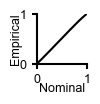

In [41]:
fig = plt.figure(figsize=(0.65, .65))

plt.plot(alpha_t, coverage_t.mean(0), color="black")
plt.xlabel('Nominal', labelpad=-2.5)
plt.ylabel('Empirical', labelpad=-1.5)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xticks([0,1], [0,1])
plt.yticks([0,1], [0,1])
fig.savefig("dmri_theta_coverage.svg", dpi=300, bbox_inches='tight', transparent=True)

In [42]:
jnp.abs(coverage[0] - alpha).mean()

Array(0.00154891, dtype=float32)